# core concepts of ml

* Explain the purpose of Train, Validation, and Test splits.
* Explain the Bias-Variance Tradeoff (what it is, how to detect).
* Define Overfitting.
* List 5 ways to combat Overfitting (e.g., regularization, dropout, augmentation, early stopping, simpler model).



In [ ]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X = pd.DataFrame(np.arange(10).reshape(5,2))
print(X)

y = pd.DataFrame(range(5))
print(y)

   0  1
0  0  1
1  2  3
2  4  5
3  6  7
4  8  9
   0
0  0
1  1
2  2
3  3
4  4


In [ ]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=2, train_size=3, random_state=42, shuffle=True, stratify=None)
# shuffle: randomly shuffles the data
# random_state: Controls the shuffling applied to the data.. why 42 Hitchhiker's Guide to the Galaxy by Douglas Adams, where 42 is revealed as "the answer to the ultimate question of life, the universe, and everything. thats why
# stratify: It ensures that if, for example, 20% of your original dataset belongs to class A and 80% to class B, then both your training and testing sets will also contain approximately 20% of class A and 80% of class B.
print("train_x")
print(train_x)
print("test_x")
print(test_x)
print("train_y")
print(train_y)
print("test_y")
print(test_y)

train_x
   0  1
2  4  5
0  0  1
3  6  7
test_x
   0  1
1  2  3
4  8  9
train_y
   0
2  2
0  0
3  3
test_y
   0
1  1
4  4


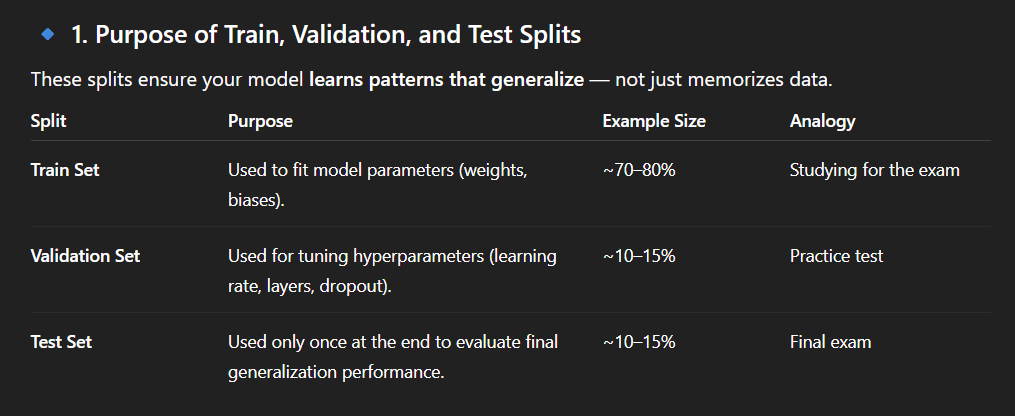

Overfitting - training with all the data, our model perform well in our data set but do bad in real world data

In [ ]:
# again split the dataset to get validation set

train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size = 1,random_state = 42, shuffle = True, stratify=None)
print("train_x")
print(train_x)
print("val_x")
print(val_x)
print("train_y")
print(train_y)
print("val_y")
print(val_y)

train_x
   0  1
0  0  1
3  6  7
val_x
   0  1
2  4  5
train_y
   0
0  0
3  3
val_y
   0
2  2


# The Bias–Variance Tradeoff

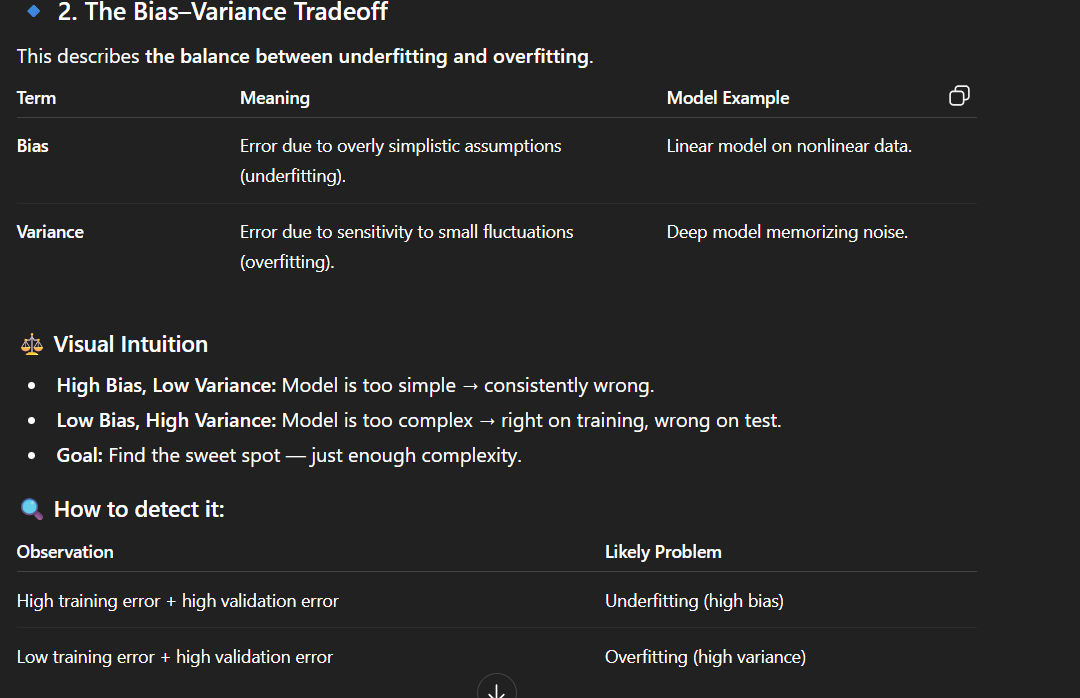

# Overfitting

when a model learns noise or random fluctuations in the training data instead of the true underlying pattern.
As a result, it performs very well on training data but poorly on new/unseen data.

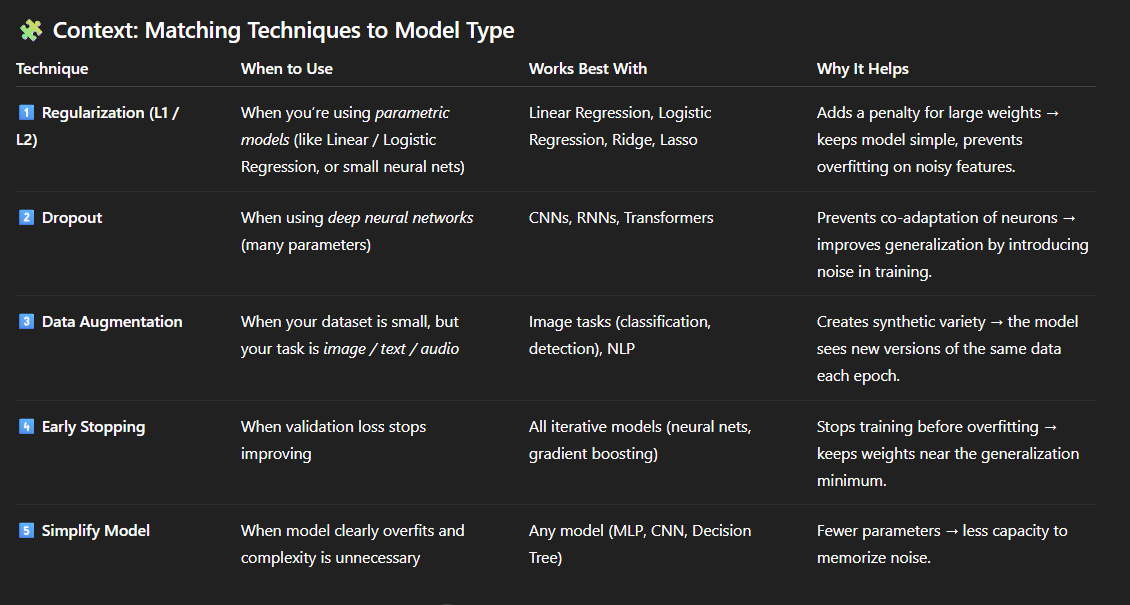

When to Combine Methods

It’s common to use multiple at once:

CNN training: Weight decay (L2) + Dropout + Data Augmentation + Early stopping

Linear model: L1/L2 regularization only

Small tabular model: Early stopping with cross-validation

In [2]:
# Regulariztion
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd

# Example data
X = pd.DataFrame({
    "horsepower": [90, 120, 150, 200, 250],
    "weight": [1.1, 1.3, 1.6, 2.0, 2.3]
})
y = [15, 20, 24, 30, 33]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# L2 Regularization (Ridge)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# L1 Regularization (Lasso)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

# L1 & L2 Regularization (Elastic Net)
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X_train, y_train)

#logesticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

print("Ridge Coefs:", ridge.coef_)
print("Lasso Coefs:", lasso.coef_)
print("Elasticnet Coefs:", elastic_net.coef_)
print("Ridge MSE:", mean_squared_error(y_test, ridge.predict(X_test)))
print("Lasso MSE:", mean_squared_error(y_test, lasso.predict(X_test)))
print("Elasticnet MSE:", mean_squared_error(y_test, elastic_net.predict(X_test)))
print("model MSE:", mean_squared_error(y_test, model.predict(X_test)))

Ridge Coefs: [0.11284507 0.15580132]
Lasso Coefs: [0.11400355 0.        ]
Elasticnet Coefs: [0.11401614 0.        ]
Ridge MSE: 0.24450710593639718
Lasso MSE: 0.23540594064403955
Elasticnet MSE: 0.23604774272192763
model MSE: 25.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# L2 regularization
$$
L = MSE + \lambda \sum_{i=1}^{n} w_i^2
$$
where:

λ = regularization strength

w = model weights

# L1 regularization
$$
L = MSE + \lambda \sum_{i=1}^{n} |w_i|
$$
where:

λ = regularization strength

L1 forces some weights to become 0 → feature selection

# Elastic Net Regularization

$$
L = MSE + \alpha \left(
\beta \sum_{i=1}^{n} |w_i| +
(1 - \beta) \sum_{i=1}^{n} w_i^2
\right)
$$
where:

α = total regularization strength

β = L1 ratio

β=1 → pure Lasso

β=0 → pure Ridge

0<β<1 → Elastic Net

In [ ]:
# lets write code for lasso and ridge from scratch
# both lasso and ridge are linear regression with applied regularization of L1 and L2

import pandas as pd
import numpy as np

# Example data
X = pd.DataFrame({
    "horsepower": [90, 120, 150, 200, 250],
    "weight": [1.1, 1.3, 1.6, 2.0, 2.3]
})
y = np.array([15, 20, 24, 30, 33])


train_x, test_x, train_y, test_y = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True, stratify=None)

# w and b
x_features = train_x.shape[1]
W = np.zeros(x_features)
b = 1

# linear regression
def linearRegression(x, W, b):
  return np.dot(x, W) + b

pre_y = linearRegression(train_x, W, b)


#MSE
def MSE(pre_y, train_y):
  mse = np.mean((train_y - pre_y)**2)
  return mse

loss = MSE(pre_y, train_y)
print(loss)

#Gradient descent with L1(lasso)
def grad(train_x, train_y, W, b):

  pre_y = linearRegression(train_x, W, b)
  n = train_x.shape[0]
  #learning rate
  alpha = 0.1
  lamda = 0.1

  #WRT weight
  dW = (-2/n) * np.dot(train_x.T, pre_y - train_y) + lamda * np.sign(W) # lasso

  #WRT bais
  db = (-2/n) * np.sum(pre_y - train_y)

  W = W - dW*alpha
  b = b - db*alpha

  return W,b

for epochs in range(10):
  print("Epochs : ", epochs)
  print("weight : ", W)
  print("bais : ", b)
  print("MSE : ", MSE(linearRegression(train_x, W, b), train_y))
  print("predict : ", linearRegression(train_x, W, b))
  W, b = grad(train_x, train_y, W, b)


647.5
Epochs :  0
weight :  [0. 0.]
bais :  1
MSE :  647.5
predict :  [1. 1. 1. 1.]
Epochs :  1
weight :  [-925.5    -9.19]
bais :  -3.9000000000000004
MSE :  28517429830.19366
predict :  [-231400.037 -138843.604  -83309.009 -185122.28 ]
Epochs :  2
weight :  [-6161826.323     -60831.43607]
bais :  -31942.7465
MSE :  1.263702897476971e+18
predict :  [-1.54062844e+09 -9.24403221e+08 -5.54663226e+08 -1.23251887e+09]
Epochs :  3
weight :  [-4.10182156e+10 -4.04943733e+08]
bais :  -212642635.54192448
MSE :  5.599891112428428e+25
predict :  [-1.02556979e+13 -6.15359290e+12 -3.69229749e+12 -8.20466565e+12]
Epochs :  4
weight :  [-2.73051184e+14 -2.69564056e+12]
bais :  -1415525340225.7778
MSE :  2.481499451625798e+33
predict :  [-6.82704115e+16 -4.09634062e+16 -2.45789873e+16 -5.46170436e+16]
Epochs :  5
weight :  [-1.81765462e+18 -1.79444141e+16]
bais :  -9422907956577584.0
MSE :  1.0996355830477478e+41
predict :  [-4.54464350e+20 -2.72686327e+20 -1.63618078e+20 -3.63576236e+20]
Epochs :  6

In [ ]:
#testing
print(linearRegression(test_x, W, b))
print(test_y)

[-2.85156041e+39]
[20]


In [ ]:
# lets write code for lasso and ridge from scratch
# both lasso and ridge are linear regression with applied regularization of L1 and L2

import pandas as pd
import numpy as np

# Example data
X = pd.DataFrame({
    "horsepower": [90, 120, 150, 200, 250],
    "weight": [1.1, 1.3, 1.6, 2.0, 2.3]
})
y = np.array([15, 20, 24, 30, 33])


train_x, test_x, train_y, test_y = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True, stratify=None)

# w and b
x_features = train_x.shape[1]
W = np.zeros(x_features)
b = 1

# linear regression
def linearRegression(x, W, b):
  return np.dot(x, W) + b

pre_y = linearRegression(train_x, W, b)


#MSE
def MSE(pre_y, train_y):
  mse = np.mean((train_y - pre_y)**2)
  return mse

loss = MSE(pre_y, train_y)
print(loss)

#Gradient descent with L1(lasso)
def grad(train_x, train_y, W, b):

  pre_y = linearRegression(train_x, W, b)
  n = train_x.shape[0]
  #learning rate
  alpha = 0.1
  lamda = 0.1

  #WRT weight
  dW = (-2/n) * np.dot(train_x.T, pre_y - train_y) + lamda * W * 2

  #WRT bais
  db = (-2/n) * np.sum(pre_y - train_y)

  W = W - dW*alpha
  b = b - db*alpha

  return W,b

for epochs in range(10):
  print("Epochs : ", epochs)
  print("weight : ", W)
  print("bais : ", b)
  print("MSE : ", MSE(linearRegression(train_x, W, b), train_y))
  print("predict : ", linearRegression(train_x, W, b))
  W, b = grad(train_x, train_y, W, b)


647.5
Epochs :  0
weight :  [0. 0.]
bais :  1
MSE :  647.5
predict :  [1. 1. 1. 1.]
Epochs :  1
weight :  [-925.5    -9.19]
bais :  -3.9000000000000004
MSE :  28517429830.19366
predict :  [-231400.037 -138843.604  -83309.009 -185122.28 ]
Epochs :  2
weight :  [-6161807.823     -60831.26227]
bais :  -31942.7465
MSE :  1.2636953095547238e+18
predict :  [-1.54062381e+09 -9.24400446e+08 -5.54661561e+08 -1.23251517e+09]
Epochs :  3
weight :  [-4.10179692e+10 -4.04941301e+08]
bais :  -212641997.23109448
MSE :  5.59982383995331e+25
predict :  [-1.02556363e+13 -6.15355593e+12 -3.69227531e+12 -8.20461637e+12]
Epochs :  4
weight :  [-2.73048724e+14 -2.69561627e+12]
bais :  -1415516838375.4849
MSE :  2.4814547305358345e+33
predict :  [-6.82697963e+16 -4.09630370e+16 -2.45787658e+16 -5.46165515e+16]
Epochs :  5
weight :  [-1.81763278e+18 -1.79441985e+16]
bais :  -9422823051651062.0
MSE :  1.0996091583748839e+41
predict :  [-4.54458890e+20 -2.72683051e+20 -1.63616112e+20 -3.63571867e+20]
Epochs :  

In [ ]:
#testing
print(linearRegression(test_x, W, b))
print(test_y)


[-2.85156041e+39]
[20]
